In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
from scipy.ndimage import gaussian_filter
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std





In [14]:
# -------------------------------
# 1. Load FITS files
# -------------------------------
fits_files = sorted(glob.glob(r"D:\Pratyay\Observations sorted\Tracking 28059\tracking1\*.fits"))



In [15]:
positions = []
times = []

# -------------------------------
# 2. Loop through each image
# -------------------------------
for i, file in enumerate(fits_files):
    hdul = fits.open(file)
    data = hdul[0].data.astype(float)

    # Optional: subtract median background
    data -= np.median(data)

    # Smooth slightly to suppress noise
    data_smooth = gaussian_filter(data, sigma=1)

    # Estimate noise
    bkg_sigma = mad_std(data_smooth)

    # -------------------------------
    # 3. Detect sources
    # -------------------------------
    daofind = DAOStarFinder(fwhm=3.0, threshold=0.1*bkg_sigma)
    sources = daofind(data_smooth)
    #sources = sources[sources['sharpness'] > 0.3]

    if sources is None:
        continue

    # -------------------------------
    # 4. Select satellite
    # -------------------------------
    # Satellite is usually the most compact + brightest
    # We use peak brightness here
    brightest = sources[np.argmax(sources['peak'])]

    x = brightest['xcentroid']
    y = brightest['ycentroid']

    positions.append((x, y))
    times.append(i)  # Replace with actual timestamps if available

    hdul.close()

positions = np.array(positions)


if len(positions) == 0:
    raise ValueError("No satellite detected")

In [31]:
# -------------------------------
# 5. Compute displacement
# -------------------------------
positions_plot = positions[:-3]
times_plot = times[:-3]

x0, y0 = positions_plot[0]

dx = positions_plot[:, 0] - x0
dy = positions_plot[:, 1] - y0

# Total displacement
dr = np.sqrt(dx**2 + dy**2)

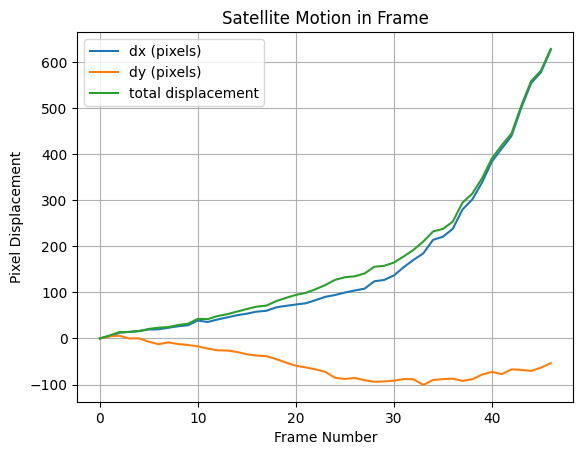

In [34]:
# -------------------------------
# 6. Plot results
# -------------------------------
plt.figure()
plt.plot(times_plot, dx, label='dx (pixels)')
plt.plot(times_plot, dy, label='dy (pixels)')
plt.plot(times_plot, dr, label='total displacement')
plt.xlabel("Frame Number")
plt.ylabel("Pixel Displacement")
plt.legend()
plt.title("Satellite Motion in Frame")
plt.grid()
plt.show()



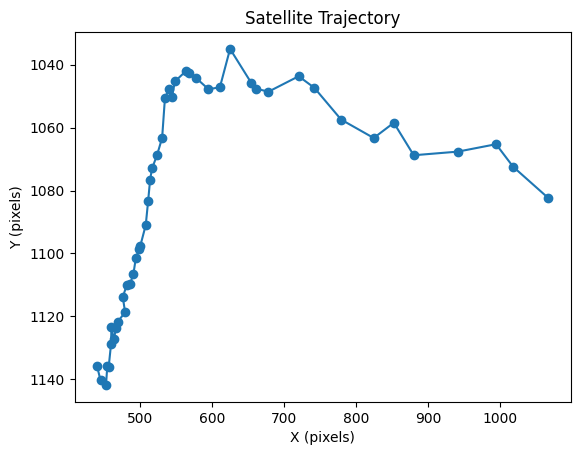

In [35]:
# -------------------------------
# 7. Trajectory plot
# -------------------------------
plt.figure()
plt.plot(positions_plot[:, 0], positions_plot[:, 1], marker='o')
plt.gca().invert_yaxis()
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Satellite Trajectory")
plt.show()

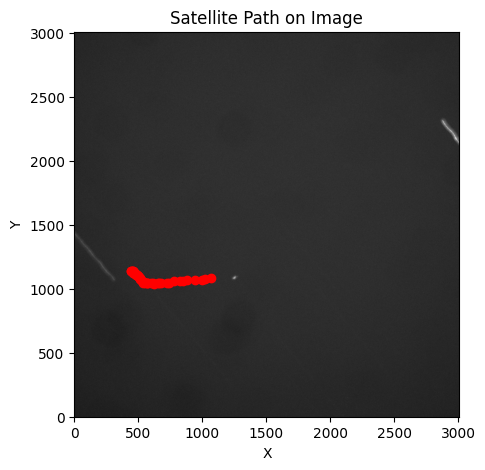

In [37]:
plt.figure(figsize=(5, 5))
plt.imshow(data, origin='lower', cmap='gray')
plt.plot(positions_plot[:, 0], positions_plot[:, 1],
         'r-o', linewidth=1)
plt.title("Satellite Path on Image")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()